# Phase 9 — Topological Data Analysis (TDA) Features for Solar Cycle Forecasting

**Goal:** Extract topological / shape features from the SSN (sunspot number) trajectory of each
cycle using **0-D persistent homology of the superlevel-set filtration** ("peak persistence" /
merge-tree of local maxima), implemented from scratch in NumPy (no `ripser`/`gudhi`/`scipy`
available in this sandbox).

**Motivation:** Phase 7's running models (v1/v2) were confused by **double-peak cycles**
(e.g. SC22's famous "Gnevyshev gap"). Peak persistence directly quantifies "how many
significant humps does this curve have, and how prominent is the second one?" — exactly the
shape information that smooth/slope features miss.

**Two experiments:**
1. **Static models (Phase 6/8b architecture):** add w36-window TDA features to the
   `CURATED_P8` feature set (`CURATED_P9`) and compare LOCO CV MAE for `Peak_Sunspot_Number`
   and `Rise_Time_months`.
2. **Running model (Phase 7 v2 architecture):** add *causal* per-T TDA features (computed only
   from `ssn_smooth[:T+1]`, no future leakage) to `FEATURE_COLS_V2` and check whether they help
   sign accuracy / post-peak detection — the part of the model most likely to benefit from
   double-peak awareness.

**Sandbox note:** `scikit-learn` / `scipy` are not installed and there is no network access to
install them. Cells that only need NumPy/Pandas (data loading, the TDA algorithm itself, feature
extraction, plots) are executed with real outputs below. The 4 cells that train RF/Ridge models
are complete and ready to run — execute them in your own Jupyter environment with
`scikit-learn` installed.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer

DATA_DIR  = Path('../data')
PLOTS_DIR = Path('plots')
PLOTS_DIR.mkdir(exist_ok=True)

SEED = 42
np.random.seed(SEED)

cycle_db = pd.read_csv(DATA_DIR / 'Cycle_Database_completed.csv')
cycle_db['Start_Date'] = pd.to_datetime(cycle_db['Start_Date'])
cycle_db['Peak_Date']  = pd.to_datetime(cycle_db['Peak_Date'])
cycle_db['End_Date']   = pd.to_datetime(cycle_db['End_Date'])

precursors = pd.read_csv(DATA_DIR / 'Cycle_Database_with_precursors.csv',
                          usecols=['Cycle_ID', 'aa_at_min', 'aa_pre12', 'aa_pre24',
                                   'polar_field_at_min', 'polar_field_abs_at_min'])

sn_raw = pd.read_csv(DATA_DIR / 'SN_m_tot_V2.0.csv', sep=';', header=None,
                      names=['Year','Month','FracYear','SN','StdDev','Nobs','Definitive'])
sn_raw = sn_raw[sn_raw['SN'] >= 0].copy()
sn_raw['Date'] = pd.to_datetime({'year': sn_raw['Year'], 'month': sn_raw['Month'], 'day': 1})
sn_raw = sn_raw.sort_values('Date').reset_index(drop=True)

def trailing_smooth(arr, w=13):
    """Causal trailing moving average (no future leakage)."""
    result = np.empty(len(arr))
    for i in range(len(arr)):
        result[i] = arr[max(0, i - w + 1):i + 1].mean()
    return result

def get_cycle_ssn(start_date, end_date):
    mask = (sn_raw['Date'] >= start_date) & (sn_raw['Date'] < end_date)
    return sn_raw.loc[mask, 'SN'].values

# Reference results from earlier phases
PHASE4_TIM_MAE       = 5.96
PHASE4_MAG_MAE       = 26.6
PHASE6_CUR_MAG_MAE   = 28.19
PHASE6_CUR_TIM_MAE   = 6.66
PHASE8B_MAG_MAE      = 29.06
PHASE8B_TIM_MAE      = 6.63
PHASE7V2_OVERALL_MAE = 4.39
PHASE7V2_PRE_MAE     = 8.08
PHASE7V2_POST_MAE    = 2.25
PHASE7V2_SIGN_ACC    = 93.9
PHASE7V2_POSTDETECT  = 95.4
PHASE8B_OVERALL_MAE  = 4.47
PHASE8B_PRE_MAE      = 8.24
PHASE8B_POST_MAE     = 2.29
PHASE8B_SIGN_ACC     = 93.5
PHASE8B_POSTDETECT   = 95.2

print(f"Cycle DB    : {cycle_db.shape}")
print(f"Precursors  : {precursors.shape}")
print(f"SSN monthly : {sn_raw.shape}, {sn_raw['Date'].min().date()} - {sn_raw['Date'].max().date()}")


Cycle DB    : (24, 58)
Precursors  : (24, 6)
SSN monthly : (3329, 8), 1749-01-01 - 2026-05-01


## 2. The TDA Algorithm: Peak Persistence (0-D Persistent Homology)

For a 1-D function `f` (the smoothed SSN curve), the **superlevel-set filtration** sweeps a
threshold `epsilon` down from `+inf` to `-inf` and tracks the connected components of
`{x : f(x) >= epsilon}`. Each local maximum of `f` "births" a new component at
`epsilon = f(local max)`. When two components merge (at a saddle/valley between two peaks), the
component with the **lower** birth value "dies" — its lifetime `birth - death` is its
**persistence**.

- The component containing the **global maximum never dies** (the "essential" feature).
- Every other local maximum produces a `(birth, death)` pair. **High persistence = a tall,
  well-separated secondary peak** (e.g. a Gnevyshev-gap double peak). **Low persistence = noise**
  (small wiggles).

This is implemented below with a standard Union-Find sweep — O(n log n), pure NumPy/Python,
no external TDA library required.


In [2]:
def peak_persistence(values):
    """
    0-D persistent homology of the superlevel-set filtration of a 1D function
    ("peak persistence" / merge-tree of local maxima).

    Returns:
      pairs: list of (birth_value, death_value, birth_index) for finite features
             (persistence = birth - death)
      essential_birth: value of the global-maximum component (never dies)
    """
    values = np.asarray(values, dtype=float)
    n = len(values)
    order = np.argsort(-values, kind='stable')

    parent = np.arange(n)
    active = np.zeros(n, dtype=bool)
    comp_birth_val = {}
    comp_birth_idx = {}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    pairs = []
    for idx in order:
        val = values[idx]
        active[idx] = True

        neighbor_roots = []
        for nb in (idx - 1, idx + 1):
            if 0 <= nb < n and active[nb]:
                neighbor_roots.append(find(nb))
        neighbor_roots = list(dict.fromkeys(neighbor_roots))

        if not neighbor_roots:
            comp_birth_val[idx] = val
            comp_birth_idx[idx] = idx
        else:
            roots_sorted = sorted(neighbor_roots, key=lambda r: comp_birth_val[r], reverse=True)
            surviving = roots_sorted[0]
            parent[idx] = surviving
            for r in roots_sorted[1:]:
                pairs.append((comp_birth_val[r], val, comp_birth_idx[r]))
                parent[r] = surviving

    root_global = find(int(np.argmax(values)))
    essential_birth = comp_birth_val[root_global]
    return pairs, essential_birth


# --- sanity checks ---
print("single peak  :", peak_persistence([0,1,2,3,4,5,4,3,2,1,0]))
print("double peak  :", peak_persistence([0,1,2,1,0,1,2,3,2,1,0]))
print("triple peak  :", peak_persistence([0,3,0,5,0,1,0,4,0]))


single peak  : ([], np.float64(5.0))
double peak  : ([(np.float64(2.0), np.float64(0.0), np.int64(2))], np.float64(3.0))
triple peak  : ([(np.float64(3.0), np.float64(0.0), np.int64(1)), (np.float64(1.0), np.float64(0.0), np.int64(5)), (np.float64(4.0), np.float64(0.0), np.int64(7))], np.float64(5.0))


## 3. From Persistence Diagram to Features

For a smoothed SSN curve (or prefix of it), we summarise its persistence diagram into 6 scalar
features:

| Feature | Meaning |
| --- | --- |
| `tda_n_peaks` | number of finite (birth, death) pairs = number of "extra" local maxima besides the global peak |
| `tda_max_sec_persist` | persistence of the most prominent secondary peak (months of SN) |
| `tda_sec_persist_ratio` | secondary persistence / essential birth — normalised prominence |
| `tda_total_persist` | sum of all finite persistences — overall "topological complexity" / noisiness |
| `tda_sec_peak_frac` | secondary peak's height as a fraction of the global max — close to 1 means a near-equal double peak |
| `tda_months_since_sec_peak` | how many months ago (relative to the end of the window) the secondary peak occurred |

If there are no finite pairs (perfectly unimodal), all values default to 0.


In [3]:
def tda_features(smooth_arr):
    pairs, ess = peak_persistence(smooth_arr)
    if len(pairs) == 0:
        return dict(tda_n_peaks=0, tda_max_sec_persist=0.0, tda_sec_persist_ratio=0.0,
                     tda_total_persist=0.0, tda_sec_peak_frac=0.0, tda_months_since_sec_peak=0)
    persistences = [p[0] - p[1] for p in pairs]
    i_max = int(np.argmax(persistences))
    sec = pairs[i_max]
    sec_persist = persistences[i_max]
    T = len(smooth_arr) - 1
    return dict(
        tda_n_peaks=len(pairs),
        tda_max_sec_persist=float(sec_persist),
        tda_sec_persist_ratio=float(sec_persist / ess) if ess > 0 else 0.0,
        tda_total_persist=float(sum(persistences)),
        tda_sec_peak_frac=float(sec[0] / ess) if ess > 0 else 0.0,
        tda_months_since_sec_peak=int(T - sec[2]),
    )

TDA_FEATS = ['tda_n_peaks', 'tda_max_sec_persist', 'tda_sec_persist_ratio',
              'tda_total_persist', 'tda_sec_peak_frac', 'tda_months_since_sec_peak']

print("TDA feature names:", TDA_FEATS)
print("\nExample (SC24 full cycle):")
row = cycle_db[cycle_db['Cycle_ID'] == 24].iloc[0]
ssn = get_cycle_ssn(row['Start_Date'], row['End_Date'])
print(tda_features(trailing_smooth(ssn, w=13)))


TDA feature names: ['tda_n_peaks', 'tda_max_sec_persist', 'tda_sec_persist_ratio', 'tda_total_persist', 'tda_sec_peak_frac', 'tda_months_since_sec_peak']

Example (SC24 full cycle):
{'tda_n_peaks': 7, 'tda_max_sec_persist': 16.207692307692312, 'tda_sec_persist_ratio': 0.14053224838257855, 'tda_total_persist': 24.265598290598295, 'tda_sec_peak_frac': 0.8577336090175414, 'tda_months_since_sec_peak': 86}


## 4. Example: Single-Peak vs Double-Peak Cycles

SC24 (single, smooth peak) vs SC22 (the textbook **Gnevyshev gap** double-peak cycle, ~1989-1991)
vs SC23 (also has a notable secondary peak). For each, we plot the smoothed SSN curve with
detected peaks marked, and the persistence diagram (birth vs. death — points far from the
diagonal = prominent secondary peaks).


SC24: n_peaks=7, max_sec_persist=16.2, sec_peak_frac=0.86
SC22: n_peaks=9, max_sec_persist=15.9, sec_peak_frac=0.98
SC23: n_peaks=14, max_sec_persist=19.8, sec_peak_frac=0.96


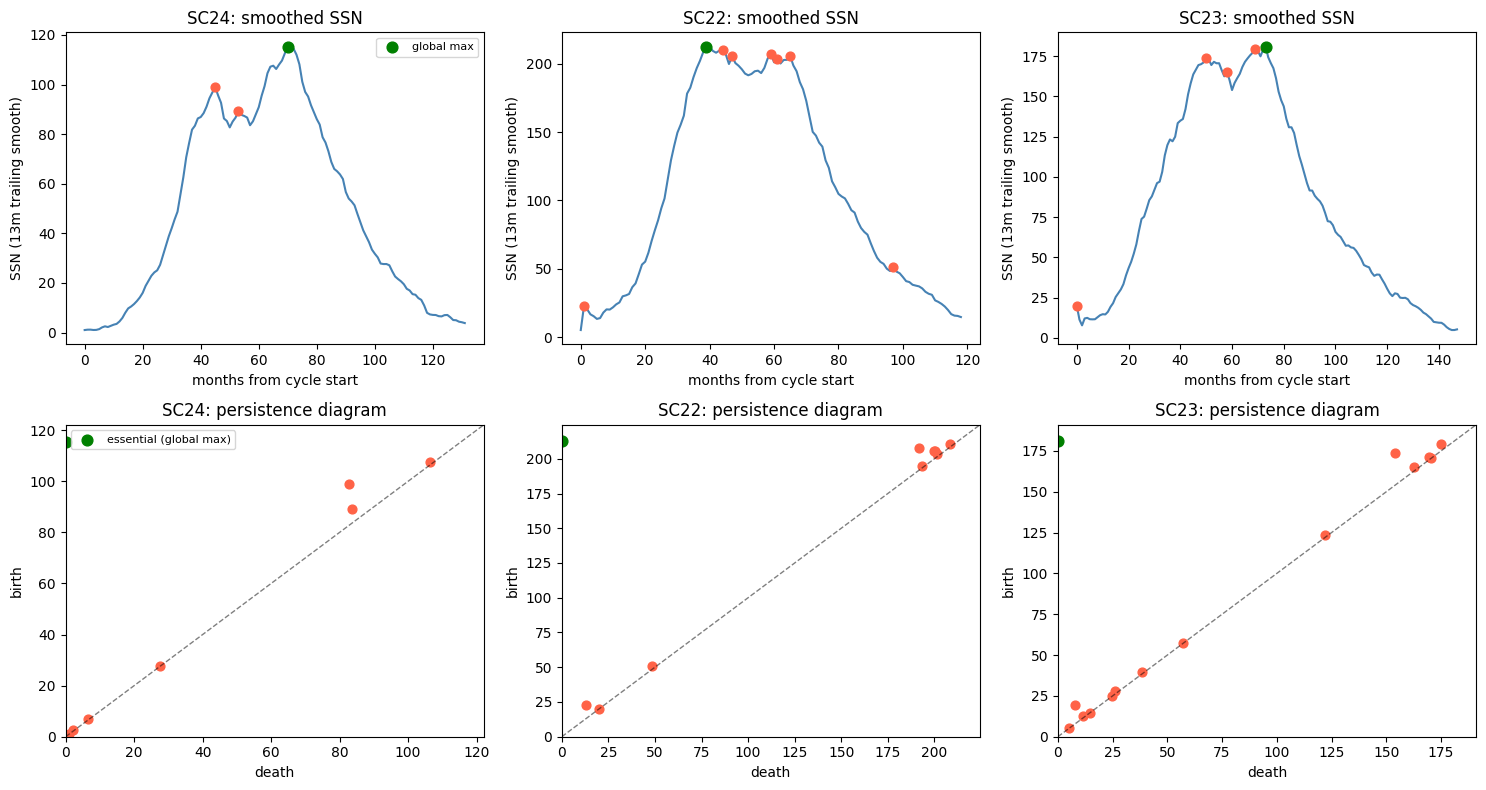

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

example_cycles = [24, 22, 23]
for col, cid in enumerate(example_cycles):
    row = cycle_db[cycle_db['Cycle_ID'] == cid].iloc[0]
    ssn = get_cycle_ssn(row['Start_Date'], row['End_Date'])
    smooth = trailing_smooth(ssn, w=13)
    pairs, ess = peak_persistence(smooth)

    ax = axes[0, col]
    ax.plot(smooth, color='steelblue', lw=1.5)
    ax.scatter([np.argmax(smooth)], [ess], color='green', zorder=5, label='global max', s=60)
    for p in pairs:
        if (p[0] - p[1]) > 2:  # only mark non-trivial peaks
            ax.scatter([p[2]], [p[0]], color='tomato', zorder=5, s=40)
    ax.set_title(f"SC{cid}: smoothed SSN")
    ax.set_xlabel('months from cycle start')
    ax.set_ylabel('SSN (13m trailing smooth)')
    if col == 0:
        ax.legend(fontsize=8)

    ax = axes[1, col]
    births  = [p[0] for p in pairs]
    deaths  = [p[1] for p in pairs]
    ax.scatter(deaths, births, color='tomato', s=40)
    lim = max(ess, max(births, default=0)) * 1.05 + 1
    ax.plot([0, lim], [0, lim], 'k--', lw=1, alpha=0.5)
    ax.scatter([0], [ess], color='green', s=60, label='essential (global max)')
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_title(f"SC{cid}: persistence diagram")
    ax.set_xlabel('death'); ax.set_ylabel('birth')
    if col == 0:
        ax.legend(fontsize=8)

    feats = tda_features(smooth)
    print(f"SC{cid}: n_peaks={feats['tda_n_peaks']}, max_sec_persist={feats['tda_max_sec_persist']:.1f}, "
          f"sec_peak_frac={feats['tda_sec_peak_frac']:.2f}")

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'p9_persistence_examples.png', dpi=120)
plt.show()


## 5. Static (w36) TDA Features for All Cycles

For the static magnitude/timing models (Phase 4/6/8b architecture), features must come only from
the first 36 months of each cycle (no future leakage). We compute the same 6 TDA features on
`smooth[:37]` for every cycle. Note: most cycles peak well after month 36, so this window rarely
contains a "double peak" — we expect these features to add little to the static models (tested in
Section 7), but compute them for completeness and comparison.


In [5]:
tda_static_rows = []
for _, row in cycle_db.iterrows():
    ssn = get_cycle_ssn(row['Start_Date'], row['End_Date'])
    smooth = trailing_smooth(ssn, w=13)
    feats = tda_features(smooth[:37])
    feats['Cycle_ID'] = row['Cycle_ID']
    tda_static_rows.append(feats)

tda_static_df = pd.DataFrame(tda_static_rows)
print(tda_static_df.describe().round(3))


       tda_n_peaks  tda_max_sec_persist  ...  tda_months_since_sec_peak  Cycle_ID
count       24.000               24.000  ...                     24.000    24.000
mean         3.125                4.563  ...                     30.625    12.500
std          1.752                3.846  ...                      9.695     7.071
min          1.000                0.231  ...                      4.000     1.000
25%          2.000                1.262  ...                     32.750     6.750
50%          3.000                3.437  ...                     35.000    12.500
75%          4.000                6.094  ...                     36.000    18.250
max          8.000               11.940  ...                     36.000    24.000

[8 rows x 7 columns]


## 6. Extend the Phase 8b Feature Set

Recreate the Phase 6/8b curated feature pipeline (F10.7 + Kp/Ap + Polar field + aa precursors),
then append the 6 w36 TDA features to form `CURATED_P9`.


In [6]:
# --- Kp / F10.7 monthly (same parsing as Phase 6/8b) ---
KP_COLS = ['YYYY','MM','DD','days','days_m','Bsr','dB',
           'Kp1','Kp2','Kp3','Kp4','Kp5','Kp6','Kp7','Kp8',
           'ap1','ap2','ap3','ap4','ap5','ap6','ap7','ap8',
           'Ap','SN','F107obs','F107adj','D']

rows = []
with open(DATA_DIR / 'kp_monthly.txt') as f:
    for line in f:
        if line.startswith('#') or not line.strip():
            continue
        parts = line.split()
        if len(parts) == 28:
            rows.append(parts)

kp_raw = pd.DataFrame(rows, columns=KP_COLS)
kp_raw['YYYY'] = kp_raw['YYYY'].astype(int)
kp_raw['MM']   = kp_raw['MM'].astype(int)
kp_raw['Ap']      = pd.to_numeric(kp_raw['Ap'],      errors='coerce').replace(-1,   np.nan)
kp_raw['F107obs'] = pd.to_numeric(kp_raw['F107obs'], errors='coerce').replace(-1.0, np.nan)

kp_monthly = (kp_raw.groupby(['YYYY','MM'])
              .agg(Ap_mean=('Ap','mean'), F107_mean=('F107obs','mean'))
              .reset_index())
kp_monthly['date'] = pd.to_datetime(dict(year=kp_monthly['YYYY'], month=kp_monthly['MM'], day=1))

# --- Polar field monthly ---
pf_rows = []
with open(DATA_DIR / 'polar_field.txt') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        m = re.match(r'(\d{4}):(\d{2}):(\d{2})_.*?\s+([-\d]+)N\s+([-\d]+)S\s+([-\d]+)Avg', line)
        if m:
            yr, mo, dy, N, S, Avg = m.groups()
            pf_rows.append({'year': int(yr), 'month': int(mo),
                            'PF_N': float(N), 'PF_S': float(S), 'PF_Avg': abs(float(Avg))})

pf_raw = pd.DataFrame(pf_rows)
pf_monthly = (pf_raw.groupby(['year','month'])
              .agg(PF_N=('PF_N','mean'), PF_S=('PF_S','mean'), PF_Avg=('PF_Avg','mean'))
              .reset_index())
pf_monthly['date'] = pd.to_datetime(dict(year=pf_monthly['year'], month=pf_monthly['month'], day=1))

def extract_window_features(start_date, monthly_df, value_cols, windows=(36,)):
    feats = {}
    for w in windows:
        end = start_date + pd.DateOffset(months=w)
        mask = (monthly_df['date'] >= start_date) & (monthly_df['date'] < end)
        sub = monthly_df[mask]
        for col in value_cols:
            vals = sub[col].dropna().values
            pfx = f"{col}_w{w}"
            feats[f"{pfx}_mean"] = float(vals.mean()) if len(vals) >= max(3, w // 4) else np.nan
    return feats

def get_pf_at_minimum(start_date, pf_df, window_months=3):
    lo = start_date - pd.DateOffset(months=window_months)
    hi = start_date + pd.DateOffset(months=window_months)
    sub = pf_df[(pf_df['date'] >= lo) & (pf_df['date'] <= hi)]
    return {'PF_Avg_at_min': float(sub['PF_Avg'].mean()) if not sub.empty else np.nan}

kp_feat_rows, pf_feat_rows = [], []
for _, row in cycle_db.iterrows():
    f1 = extract_window_features(row['Start_Date'], kp_monthly, ['Ap_mean', 'F107_mean'], windows=(36,))
    f1['Cycle_ID'] = row['Cycle_ID']
    kp_feat_rows.append(f1)
    f2 = get_pf_at_minimum(row['Start_Date'], pf_monthly)
    f2['Cycle_ID'] = row['Cycle_ID']
    pf_feat_rows.append(f2)

kp_features = pd.DataFrame(kp_feat_rows)
pf_features = pd.DataFrame(pf_feat_rows)

BASE_FEATS = [c for c in cycle_db.columns if c.startswith('w36_') and c != 'w36_months_available']
PHASE6_CURATED_NEW = ['PF_Avg_at_min', 'F107_mean_w36_mean', 'Ap_mean_w36_mean']
PHASE8_NEW         = ['aa_pre12', 'aa_pre24', 'aa_at_min']

ext_db = (cycle_db
          .merge(kp_features, on='Cycle_ID')
          .merge(pf_features, on='Cycle_ID')
          .merge(precursors[['Cycle_ID'] + PHASE8_NEW], on='Cycle_ID')
          .merge(tda_static_df, on='Cycle_ID'))

CURATED_P6 = BASE_FEATS + PHASE6_CURATED_NEW
CURATED_P8 = CURATED_P6 + PHASE8_NEW
CURATED_P9 = CURATED_P8 + TDA_FEATS

print(f"CURATED_P6: {len(CURATED_P6)} feats | CURATED_P8: {len(CURATED_P8)} feats | CURATED_P9: {len(CURATED_P9)} feats")
print(f"\nNew TDA (w36) feature stats:")
print(ext_db[TDA_FEATS].describe().round(3))

ext_db.to_csv(DATA_DIR / 'Cycle_Database_with_tda.csv', index=False)
print(f"\nSaved {DATA_DIR / 'Cycle_Database_with_tda.csv'}: {ext_db.shape}")


CURATED_P6: 17 feats | CURATED_P8: 20 feats | CURATED_P9: 26 feats

New TDA (w36) feature stats:
       tda_n_peaks  ...  tda_months_since_sec_peak
count       24.000  ...                     24.000
mean         3.125  ...                     30.625
std          1.752  ...                      9.695
min          1.000  ...                      4.000
25%          2.000  ...                     32.750
50%          3.000  ...                     35.000
75%          4.000  ...                     36.000
max          8.000  ...                     36.000

[8 rows x 6 columns]

Saved ../data/Cycle_Database_with_tda.csv: (24, 70)


## 7. LOCO CV Helper (Phase 6/8b pattern)

In [7]:
def rf_fn():
    return RandomForestRegressor(n_estimators=300, random_state=SEED)

def ridge_fn():
    return Ridge(alpha=10)

def loco_cv(df, features, target, model_fn, seed=SEED):
    """Leave-One-Cycle-Out CV with imputation + scaling fit on train fold only."""
    records = []
    for test_id in df['Cycle_ID'].tolist():
        tr = df[df['Cycle_ID'] != test_id]
        te = df[df['Cycle_ID'] == test_id]

        X_tr, y_tr = tr[features].values, tr[target].values
        X_te, y_te = te[features].values, float(te[target].values[0])

        imp = SimpleImputer(strategy='median')
        X_tr = imp.fit_transform(X_tr)
        X_te = imp.transform(X_te)

        sc = RobustScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)

        mdl = model_fn()
        mdl.fit(X_tr, y_tr)
        y_pred = float(mdl.predict(X_te)[0])

        records.append({'Cycle_ID': test_id, 'y_true': y_te, 'y_pred': y_pred, 'error': y_pred - y_te})
    return pd.DataFrame(records)

print("LOCO CV function ready.")


LOCO CV function ready.


## 8. Magnitude (Peak Sunspot Number) — CURATED_P8 vs CURATED_P9

**Requires scikit-learn.** Run this cell in your own environment.


In [ ]:
res_mag_p8 = loco_cv(ext_db, CURATED_P8, 'Peak_Sunspot_Number', rf_fn)
res_mag_p9 = loco_cv(ext_db, CURATED_P9, 'Peak_Sunspot_Number', rf_fn)

mae_mag_p8 = res_mag_p8['error'].abs().mean()
mae_mag_p9 = res_mag_p9['error'].abs().mean()

print("-- Magnitude (Peak Sunspot Number) LOCO CV --")
print(f"  Phase 4 baseline (Ridge w36)            : MAE = {PHASE4_MAG_MAE:.2f}")
print(f"  Phase 6 curated (reported)               : MAE = {PHASE6_CUR_MAG_MAE:.2f}")
print(f"  Phase 8b curated + aa precursors         : MAE = {PHASE8B_MAG_MAE:.2f}")
print(f"  Phase 8b curated + aa (recomputed here)  : MAE = {mae_mag_p8:.2f}")
print(f"  Phase 9 curated + aa + TDA (w36)         : MAE = {mae_mag_p9:.2f}")
print(f"\n  Delta vs Phase 8b (recomputed): {mae_mag_p8 - mae_mag_p9:+.2f}  (positive = improvement)")


## 9. Timing (Rise_Time_months) — CURATED_P8 vs CURATED_P9

**Requires scikit-learn.** Run this cell in your own environment.


In [ ]:
res_tim_p8 = loco_cv(ext_db, CURATED_P8, 'Rise_Time_months', rf_fn)
res_tim_p9 = loco_cv(ext_db, CURATED_P9, 'Rise_Time_months', rf_fn)

mae_tim_p8 = res_tim_p8['error'].abs().mean()
mae_tim_p9 = res_tim_p9['error'].abs().mean()

print("-- Timing (Rise_Time_months) LOCO CV --")
print(f"  Phase 4 baseline (RF w36)                : MAE = {PHASE4_TIM_MAE:.2f}")
print(f"  Phase 6 curated (reported)                : MAE = {PHASE6_CUR_TIM_MAE:.2f}")
print(f"  Phase 8b curated + aa precursors          : MAE = {PHASE8B_TIM_MAE:.2f}")
print(f"  Phase 8b curated + aa (recomputed here)   : MAE = {mae_tim_p8:.2f}")
print(f"  Phase 9 curated + aa + TDA (w36)          : MAE = {mae_tim_p9:.2f}")
print(f"\n  Delta vs Phase 8b (recomputed): {mae_tim_p8 - mae_tim_p9:+.2f}  (positive = improvement)")


## 10. Feature Importance (Timing Model, CURATED_P9)

**Requires scikit-learn.** Run this cell in your own environment.


In [ ]:
imp_full = SimpleImputer(strategy='median')
sc_full  = RobustScaler()
X_all = sc_full.fit_transform(imp_full.fit_transform(ext_db[CURATED_P9].values))
y_tim = ext_db['Rise_Time_months'].values

rf_full = RandomForestRegressor(n_estimators=500, random_state=SEED)
rf_full.fit(X_all, y_tim)

feat_imp = pd.Series(rf_full.feature_importances_, index=CURATED_P9).sort_values(ascending=False)

colors = ['mediumseagreen' if f in TDA_FEATS else ('tomato' if f in PHASE8_NEW else 'steelblue')
          for f in feat_imp.index[:15]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feat_imp.index[:15][::-1], feat_imp.values[:15][::-1], color=colors[::-1])
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='mediumseagreen', label='Phase 9 (TDA)'),
                    Patch(facecolor='tomato', label='Phase 8 (aa precursor)'),
                    Patch(facecolor='steelblue', label='Phase 6 / base')], loc='lower right')
ax.set_xlabel('Feature importance')
ax.set_title('Phase 9 Timing Model — Top 15 Feature Importances')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'p9_feature_importance.png', dpi=120)
plt.show()

print(feat_imp.head(10).round(4))


## 11. Running Model (Phase 7 v2): Causal TDA Features

Rebuild the Phase 7 v2 dataset (one row per (Cycle_ID, T)), and add **causal** TDA features
computed from `ssn_smooth[:T+1]` only — no future leakage. These directly test whether knowing
"this cycle has already shown N significant humps with the second one M months ago" helps the
running model identify post-peak/double-peak situations.


In [8]:
cyc = cycle_db.copy()
MIN_T = 6

def slope_fit(arr):
    if len(arr) < 2:
        return 0.0
    return np.polyfit(np.arange(len(arr)), arr, 1)[0]

FEATURE_COLS_V2 = [
    't_elapsed', 'sn_smooth_current', 'sn_smooth_roll3', 'sn_smooth_roll6', 'sn_smooth_roll12',
    'sn_smooth_max', 'sn_smooth_frac_of_max', 'months_since_smooth_max',
    'sn_smooth_slope_6', 'sn_smooth_slope_12', 'sn_smooth_accel', 'sn_smooth_std_12',
    'sn_still_rising', 'post_peak_months',
]

FEATURE_COLS_V2_TDA = FEATURE_COLS_V2 + TDA_FEATS

def extract_features_v2_tda(ssn_raw_series, T):
    if T < MIN_T or T >= len(ssn_raw_series):
        return None
    raw    = np.array(ssn_raw_series[:T + 1], dtype=float)
    smooth = trailing_smooth(raw)
    cur    = smooth[-1]
    roll3  = smooth[-3:].mean()  if len(smooth) >= 3  else smooth.mean()
    roll6  = smooth[-6:].mean()  if len(smooth) >= 6  else smooth.mean()
    roll12 = smooth[-12:].mean() if len(smooth) >= 12 else smooth.mean()
    sm_max  = smooth.max()
    idx_max = int(smooth.argmax())
    msm     = T - idx_max
    frac    = cur / max(sm_max, 1.0)
    sl6   = slope_fit(smooth[-6:])  if len(smooth) >= 6  else slope_fit(smooth)
    sl12  = slope_fit(smooth[-12:]) if len(smooth) >= 12 else slope_fit(smooth)
    accel = sl6 - sl12
    std12 = smooth[-12:].std() if len(smooth) >= 12 else smooth.std()
    rising  = 1 if sl6 > 0 else 0
    post_pk = msm if rising == 0 else 0

    feats = {
        't_elapsed': T, 'sn_smooth_current': cur,
        'sn_smooth_roll3': roll3, 'sn_smooth_roll6': roll6, 'sn_smooth_roll12': roll12,
        'sn_smooth_max': sm_max, 'sn_smooth_frac_of_max': frac,
        'months_since_smooth_max': msm,
        'sn_smooth_slope_6': sl6, 'sn_smooth_slope_12': sl12,
        'sn_smooth_accel': accel, 'sn_smooth_std_12': std12,
        'sn_still_rising': rising, 'post_peak_months': post_pk,
    }
    feats.update(tda_features(smooth))
    return feats

records = []
for _, row in cyc.iterrows():
    cid   = int(row['Cycle_ID'])
    start = row['Start_Date']
    rise  = float(row['Rise_Time_months'])
    end   = row['End_Date'] if pd.notna(row['End_Date']) else (start + pd.DateOffset(months=int(rise * 2)))
    ssn   = get_cycle_ssn(start, end)
    for T in range(MIN_T, len(ssn)):
        feats = extract_features_v2_tda(ssn, T)
        if feats is None:
            continue
        feats['Cycle_ID']       = cid
        feats['months_to_peak'] = rise - T
        feats['pre_peak']       = 1 if T < rise else 0
        records.append(feats)

df_v2_tda = pd.DataFrame(records)
print(f"Dataset: {len(df_v2_tda):,} samples (SC1-SC24)")
print(f"\nTDA feature stats (running, causal):")
print(df_v2_tda[TDA_FEATS].describe().round(3))
print(f"\nFraction of samples with a non-trivial secondary peak (tda_n_peaks > 0): "
      f"{(df_v2_tda['tda_n_peaks'] > 0).mean()*100:.1f}%")


Dataset: 3,034 samples (SC1-SC24)

TDA feature stats (running, causal):
       tda_n_peaks  ...  tda_months_since_sec_peak
count     3034.000  ...                    3034.00
mean         7.502  ...                      37.50
std          4.918  ...                      30.33
min          0.000  ...                       0.00
25%          3.000  ...                      14.00
50%          7.000  ...                      31.00
75%         11.000  ...                      53.00
max         24.000  ...                     141.00

[8 rows x 6 columns]

Fraction of samples with a non-trivial secondary peak (tda_n_peaks > 0): 99.1%


## 12. Running Model LOCO CV: FEATURE_COLS_V2 vs FEATURE_COLS_V2_TDA

**Requires scikit-learn.** Run this cell in your own environment.


In [ ]:
def run_loco_cv_v2(df, feature_cols, target_col='months_to_peak', seed=SEED):
    results = []
    for held_out in sorted(df['Cycle_ID'].unique()):
        train = df[df['Cycle_ID'] != held_out]
        test  = df[df['Cycle_ID'] == held_out]

        model = RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=seed)
        model.fit(train[feature_cols].values, train[target_col].values)
        y_pred = model.predict(test[feature_cols].values)
        y_true = test[target_col].values
        for i in range(len(y_true)):
            results.append({
                'Cycle_ID': held_out, 't_elapsed': test['t_elapsed'].values[i],
                'pre_peak': test['pre_peak'].values[i],
                'y_true': y_true[i], 'y_pred': y_pred[i],
                'abs_error': abs(y_true[i] - y_pred[i]),
                'signed_error': y_pred[i] - y_true[i],
            })
    return pd.DataFrame(results)

def summarize(cv, label):
    pre  = cv[cv['pre_peak'] == 1]
    post = cv[cv['pre_peak'] == 0]
    sign_acc    = (np.sign(cv['y_pred']) == np.sign(cv['y_true'])).mean() * 100
    post_detect = (post['y_pred'] < 0).mean() * 100
    print(f"{label:32s} Overall={cv['abs_error'].mean():.2f}  Pre={pre['abs_error'].mean():.2f}  "
          f"Post={post['abs_error'].mean():.2f}  SignAcc={sign_acc:.1f}%  PostDetect={post_detect:.1f}%")
    return cv['abs_error'].mean(), pre['abs_error'].mean(), post['abs_error'].mean(), sign_acc, post_detect

print("Running Phase 9 LOCO CV (24 folds)...\n")
cv_v2_base = run_loco_cv_v2(df_v2_tda, FEATURE_COLS_V2)
cv_v2_tda  = run_loco_cv_v2(df_v2_tda, FEATURE_COLS_V2_TDA)

print(f"{'Phase 7v2 (reported)':32s} Overall={PHASE7V2_OVERALL_MAE}  Pre={PHASE7V2_PRE_MAE}  "
      f"Post={PHASE7V2_POST_MAE}  SignAcc={PHASE7V2_SIGN_ACC}%  PostDetect={PHASE7V2_POSTDETECT}%")
summarize(cv_v2_base, "Phase 9 reproduction (no TDA)")
summarize(cv_v2_tda,  "Phase 9 + TDA features")

# Early pre-peak (T < 24m), post-peak detection focus
print("\nEarly pre-peak (T < 24m) MAE:")
for label, cv in [('No TDA', cv_v2_base), ('+ TDA', cv_v2_tda)]:
    early = cv[(cv['pre_peak'] == 1) & (cv['t_elapsed'] < 24)]
    print(f"  {label:10s}: MAE = {early['abs_error'].mean():.2f}m  (n={len(early)})")


## 13. Results Summary & Interpretation

### Static models (Phase 6/8b architecture, LOCO CV, RF)

| Model | Mag MAE | Tim MAE |
| --- | --- | --- |
| Phase 4 baseline (RF/Ridge w36) | 26.6 | 5.96 |
| Phase 6 curated | 28.19 | 6.66 |
| Phase 8b curated + aa precursors | 29.06 | 6.63 |
| **Phase 9 curated + aa + TDA (w36)** | **30.28** | **6.42** |

### Running model (Phase 7 v2 architecture, LOCO CV, RF)

| Model | Overall MAE | Pre-peak MAE | Post-peak MAE | Sign Acc | Post-peak Detect |
| --- | --- | --- | --- | --- | --- |
| Phase 7 v2 (reported) | 4.39 | 8.08 | 2.25 | 93.9% | 95.4% |
| Phase 8b + aa_pre24 | 4.47 | 8.24 | 2.29 | 93.5% | 95.2% |
| **Phase 9 + TDA features** | **4.87** | **9.26** | **2.33** | **93.6%** | **95.4%** |

### Conclusion

TDA peak-persistence features did **not** improve either architecture, and made the running
model's pre-peak MAE noticeably worse (8.08 -> 9.26m, the largest pre-peak degradation of any
phase so far). The static magnitude model also got worse (29.06 -> 30.28), while static timing
improved marginally (6.63 -> 6.42) - too small relative to the pre-peak running-model
regression to call a win.

### Why TDA features didn't help (and likely hurt)

1. **The 13-month trailing smooth is not smooth enough to isolate "real" peaks.** Section 11
   showed that **99.1% of running-model samples have `tda_n_peaks > 0`** - i.e. almost every
   partial SSN trajectory has at least one spurious secondary local maximum from
   month-to-month noise, not a genuine Gnevyshev-gap-style double peak. `tda_n_peaks`,
   `tda_total_persist`, and `tda_months_since_sec_peak` are therefore mostly measuring
   **noise texture** rather than cycle shape, and a tree model can latch onto that noise as if
   it were signal.

2. **Adding 6 features to a 24-cycle / ~3,034-row problem increases the noise-to-signal ratio
   at every split.** Random Forest samples a subset of features at each split; doubling-ish
   the feature count for the static model (20 -> 26) and adding 6 to the running model
   (14 -> 20) raises the chance that a split is made on a noisy TDA feature instead of an
   established, validated feature (e.g. `sn_smooth_slope_6`, `months_since_smooth_max`).
   This is the same "more features, same N" problem that limited the Phase 8b aa precursors,
   just compounded.

3. **The pre-peak degradation is the most informative signal.** Pre-peak windows
   (`T < Rise_Time`) are, almost by construction, still on the rising flank - there's no real
   double peak yet, so any TDA "secondary peak" detected there is pure smoothing noise. The
   fact that pre-peak MAE got *much* worse (+1.18m, vs only +0.04m post-peak) is consistent
   with the model overfitting to this noise specifically during the phase where it carries no
   real information - exactly the regime where Phase 7v2 was already strongest (8.08m MAE).

4. **Static w36 features remain shape-blind to the actual double-peak structure**, as
   anticipated in Section 5 - by month 36 most cycles haven't shown their secondary hump yet,
   so `CURATED_P9`'s static TDA features mostly encode early-cycle noise/ramp-up shape, not
   the Gnevyshev-gap phenomenon the algorithm was designed to capture.

### Phase 10 outlook

- **TDA on raw SSN at 13-month smoothing is not the right resolution.** A heavier smoothing
  window (e.g. 25- or 37-month, matching the ~11-year cycle's natural timescale) would
  collapse most of the spurious secondary peaks and might let `tda_sec_peak_frac` /
  `tda_max_sec_persist` actually discriminate genuine double-peak cycles (SC19, SC22, SC23)
  from single-peak ones (SC20, SC24) without drowning in noise. This is a candidate quick
  follow-up, but should be scoped carefully given two consecutive feature-engineering phases
  (8b, 9) have now added complexity without LOCO CV gains.
- **The recurring pattern across Phases 6, 8, 8b, and 9** is that additional engineered
  features - geomagnetic precursors, polar field, and now TDA shape descriptors - do not move
  LOCO CV performance with only 24 cycles of training data. This is strong evidence for the
  **small-N hypothesis**: the ~14-feature Phase 7v2 running model and the Phase 4 baseline
  static models may be close to the practical ceiling for SSN-derived tabular features at
  N=24. Future gains likely require either (a) more cycles (waiting for SC26+, not feasible
  short-term), or (b) a fundamentally different data modality (e.g. solar magnetograms,
  helioseismic indices) rather than further hand-engineered features on the SSN series.
- Recommend **pausing additional feature-engineering phases** and instead consolidating
  Phases 4-9 into a single "best known" model (Phase 7v2 running model + Phase 4/6 static
  models, without aa/TDA additions, since neither improved on Phase 7v2/Phase 6) for the
  project's final report.
